In [63]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.decomposition import PCA
from scipy.stats import skew
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')

In [3]:
raw = "C:\\Users\\Taavi\\Desktop\\BPhil\\Raw data\\"
clean = "C:\\Users\\Taavi\\Desktop\\BPhil\\Clean data\\"

In [ ]:
parcels = pd.read_csv(clean + 'blight.csv')
parcels['tract'] =  parcels['tract'].astype(str).str.split('.').str[0]

viols = pd.read_csv(clean + 'viols_ready_to_measure.csv')

#### Merging census tract onto viols

In [14]:
viols = (
    viols
    .merge(parcels[['parcelID', 'tract']], on = 'parcelID', how = 'inner')
    .assign(
        tract = lambda x: x['tract'].astype(str).str.split('.').str[0]
    )
)

In [18]:
n_parcels_by_tract = parcels.groupby('tract')['parcelID'].nunique().reset_index().rename(columns = {'parcelID': 'num_parcels'})
viols = viols.merge(n_parcels_by_tract, on = 'tract', how = 'left')

#### Visualizing census tracts with very low num_parcels

In [85]:
n_parcels_by_tract['num_parcels'].describe(percentiles = np.arange(0, 1.01, 0.01)).head(10)

count    138.00
mean    1043.70
std      594.50
min        1.00
0%         1.00
1%         2.74
2%        12.14
3%        17.65
4%        33.40
5%        44.50
Name: num_parcels, dtype: float64

In [74]:
toPlot = parcels.merge(n_parcels_by_tract, on = 'tract', how = 'left')
toPlot = toPlot.query('num_parcels <= 20')

In [75]:
fig = px.scatter_mapbox(toPlot, lat = 'lat', lon = 'lng', zoom = 10, hover_data = ['nbrhd', 'num_parcels'])
fig.update_layout(mapbox_style = 'carto-positron')
fig.show()

Most of these look like parks or obscure places at the edge of the city. The place that stands out is Terrace Village near Downtown. The issue is that this is a collection of cul-de-sacs, although each cul-de-sac is represented by one parcelID instead of each of the properties having their own parcelID. So it's an issue with the data. I'm just going to filter out tracts where num_parcels <= 20.

In [19]:
viols = viols.query('num_parcels > 20')

#### Counting violations in each tract (method1)

In [20]:
method_1 = (
    viols.groupby('tract')['violID'].count() /
    viols.groupby('tract')['num_parcels'].first()#.rename(columns = {'violID': 'viol_count'})
)

In [21]:
method_1.nlargest(n = 10)

tract
40600    2.20
40900    1.31
40500    1.22
170600   1.22
300100   1.21
160800   1.15
130200   1.11
130300   1.00
170200   0.96
50900    0.95
dtype: float64

In [22]:
method_1.describe()

count   132.00
mean      0.45
std       0.31
min       0.01
25%       0.26
50%       0.40
75%       0.57
max       2.20
dtype: float64

Where BPU (blight-per-unit) is highest is in Oakland and on the Southside.

In [ ]:
method_1 # this is BPU in each census tract

tract
100500   0.20
101100   0.35
101400   0.22
101600   0.34
101700   0.66
         ... 
980800   0.01
980900   0.02
981200   0.20
981800   0.13
982200   0.20
Length: 132, dtype: float64

### I'm first going to compare this code violation BPU against my code violation score
#### I need to see if this data requires skew-transformation

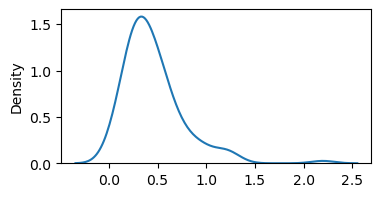

In [25]:
plt.figure(figsize = (4, 2))
sns.kdeplot(method_1)
plt.show()

In [26]:
skew(method_1)

np.float64(1.9382470010864212)

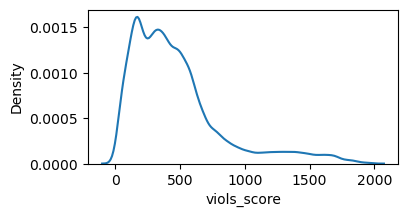

In [27]:
plt.figure(figsize = (4, 2))
sns.kdeplot(parcels['viols_score'])
plt.show()

In [28]:
skew(parcels['viols_score'])

np.float64(1.554957379535427)

#### This is one observation: my score is less skewed to begin with.
However both are skewed and I will use sqrt-transformed versions to compare, instead of the raw versions.

In [30]:
method_1_sqrt = np.sqrt(method_1)

skew(parcels['viols_sqrt']), skew(method_1_sqrt)

(np.float64(0.5943884070266415), np.float64(0.42805150005776993))

Hmm both transformed, my method is more skewed. I don't know if this is good or bad or neither

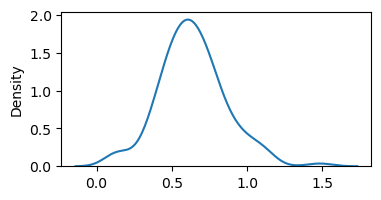

In [31]:
plt.figure(figsize = (4, 2))
sns.kdeplot(method_1_sqrt)
plt.show()

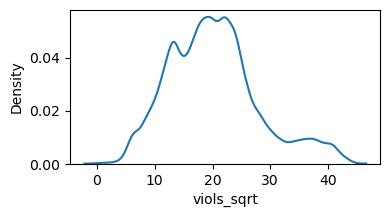

In [32]:
plt.figure(figsize = (4, 2))
sns.kdeplot(parcels['viols_sqrt'])
plt.show()

My intuition is that my version is superior because (looking at the kdeplots) it's easier to discern bumps that should represent clusters. I would argue that method_1 is too smooth

### How will I compare the effectiveness of both?

I want to use condemnations, as these are a commonly agreed-upon representation of urban blight. I am going to measure condemnations using both approaches (my own method as well as census tract BPU), and then come up with a few ways to compare from that point forward.

In [116]:
conds = pd.read_csv(clean + 'clean_condemnations.csv')

In [117]:
conds = conds.merge(parcels[['parcelID', 'lat', 'lng', 'tract']], on = 'parcelID', how = 'left').dropna()

#### Census tract BPU method

In [118]:
n_parcels_by_tract = parcels.groupby('tract')['parcelID'].nunique().reset_index().rename(columns = {'parcelID': 'num_parcels'})
conds = conds.merge(n_parcels_by_tract, on = 'tract', how = 'left')

method_1_conds = (
    conds.groupby('tract')['parcelID'].count() /
    conds.groupby('tract')['num_parcels'].first()
)

In [56]:
method_1_conds.describe()

count   118.00
mean      0.02
std       0.02
min       0.00
25%       0.01
50%       0.01
75%       0.04
max       0.08
dtype: float64

#### My method

In [57]:
full = pd.DataFrame()

earthRadius = 6_378_137 # meters

distances = np.arange(50, 800, 50)
distances_radians = distances / earthRadius
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

parcels_coords = np.radians(parcels[['lat', 'lng']].to_numpy())
conds_coords = np.radians(conds[['lat', 'lng']].to_numpy())

cond_tree = BallTree(conds_coords, metric = 'haversine')
    
    # count conds in each distance bin
for d_m, d_r in zip(distances, distances_radians):
    indices_within_radius = cond_tree.query_radius(parcels_coords, r = d_r)
    counts = [len(idxs) for idxs in indices_within_radius]
    parcels[f'conds_count_{d_m}'] = counts

parcels = parcels.fillna(0)

for i, r in enumerate(distances[::-1]):
    if r != distances[0]:
        parcels[f'conds_count_{r}'] -= parcels[f'conds_count_{distances[::-1][i + 1]}']

parcels['conds_count_decayed'] = (parcels.iloc[:, -len(distances):] * weights).sum(axis = 1)

In [59]:
parcels['conds_count_decayed'].describe()

count   144031.00
mean        19.88
std         22.43
min          0.00
25%          4.20
50%          9.87
75%         30.20
max        121.13
Name: conds_count_decayed, dtype: float64

### Now I need to decide how to compare them

I'll start by regressing the condemnation value by the code violations value. First I actually have to check heteroscedasticity.

In [ ]:
method_1_aligned = method_1_sqrt[method_1_sqrt.index.isin(method_1_conds.index)]

y_method_1 = np.asarray(method_1_conds)
X_method_1 = sm.add_constant(np.asarray(method_1_aligned))
model_method_1 = sm.OLS(y_method_1, X_method_1).fit()
resid_method_1 = model_method_1.resid
fitted_method_1 = model_method_1.fittedvalues

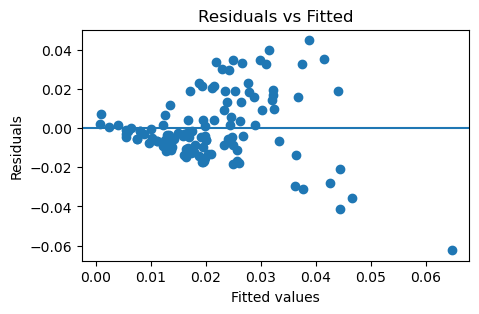

In [101]:
plt.figure(figsize = (5, 3))
plt.scatter(fitted_method_1, resid_method_1)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [108]:
y = np.asarray(parcels['conds_count_decayed'])
X = sm.add_constant(np.asarray(parcels['viols_sqrt']))
model = sm.OLS(y, X).fit()
resid = model.resid
fitted = model.fittedvalues

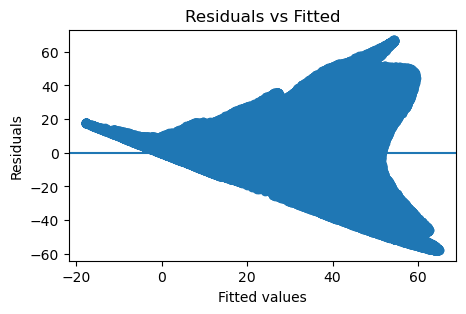

In [109]:
plt.figure(figsize = (5, 3))
plt.scatter(fitted, resid)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [113]:
method_1_df = pd.DataFrame({'BPU': method_1_aligned, 'conds': method_1_conds})

In [120]:
model = smf.ols(formula = 'conds ~ BPU', data = method_1_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  conds   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     44.28
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           9.88e-10
Time:                        00:35:04   Log-Likelihood:                 310.70
No. Observations:                 118   AIC:                            -617.4
Df Residuals:                     116   BIC:                            -611.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0152      0.006     -2.680      0.0

In [122]:
model = smf.ols(formula = 'conds_count_decayed ~ viols_sqrt', data = parcels).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     conds_count_decayed   R-squared:                       0.418
Model:                             OLS   Adj. R-squared:                  0.418
Method:                  Least Squares   F-statistic:                 1.034e+05
Date:                 Sun, 21 Dec 2025   Prob (F-statistic):               0.00
Time:                         00:35:38   Log-Likelihood:            -6.1343e+05
No. Observations:               144031   AIC:                         1.227e+06
Df Residuals:                   144029   BIC:                         1.227e+06
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.6417      0.125   -140.98

Hmmmmm. Okay. So based on this regression we see substantially better r-squared and p-value/t-statistic for my method than for the census tract BPU approach. This would mean that my method is better at distinguishing between levels of blight (if we take condemnations to be indicative of blight).

HOWEVER - both sets of data egregiously violate heteroscedasticity, so I wonder if these values can really be used.

### Commentary from Chat-GPT:

So what you are really comparing is:

How well does each spatial measurement framework produce a blight signal that aligns with a condemnation signal constructed under the same assumptions?

That is a coherent question.

You are not claiming:

“Which blight score best predicts condemnations in some absolute sense?”

You are claiming:

“Which measurement approach produces a blight signal that better co-moves with a condemnation signal under that same spatial representation?”



A defensible interpretation is:

“When blight and condemnations are measured using a common tract-based normalization, their association explains 27.6% of the variance. When both are measured using a parcel-level distance-decayed exposure framework, the association increases to 41.8%, suggesting that the latter framework better captures spatial processes linking blight to condemnations.”

That statement does not overreach.

In [141]:
m1x_m2y = parcels.groupby('tract')['conds_count_decayed'].mean().reset_index().merge(method_1_df['BPU'].reset_index(), on = 'tract', how = 'left')

In [142]:
model = smf.ols(formula = 'conds_count_decayed ~ BPU', data = m1x_m2y).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     conds_count_decayed   R-squared:                       0.276
Model:                             OLS   Adj. R-squared:                  0.270
Method:                  Least Squares   F-statistic:                     44.33
Date:                 Sun, 21 Dec 2025   Prob (F-statistic):           9.69e-10
Time:                         21:53:29   Log-Likelihood:                -501.10
No. Observations:                  118   AIC:                             1006.
Df Residuals:                      116   BIC:                             1012.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -15.2377      5.518     -2.76

In [143]:
m1y_m2x = parcels.groupby('tract')['viols_sqrt'].mean().reset_index().merge(method_1_df['conds'].reset_index(), on = 'tract', how = 'left')

In [144]:
model = smf.ols(formula = 'conds ~ viols_sqrt', data = m1y_m2x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  conds   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     34.63
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           3.94e-08
Time:                        21:53:33   Log-Likelihood:                 307.04
No. Observations:                 118   AIC:                            -610.1
Df Residuals:                     116   BIC:                            -604.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0075      0.005     -1.465      0.1